In [6]:
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('train.csv')

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8693.000000   8693.000000   8693.000000   8693.000000   8693.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.339054    659.739364   1594.434978    597.417440   1124.675871   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      20.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      37.000000     78.000000    118.000000     45.000000     89.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8693.000000  
mean     304.854791  
std     1133.259049  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       71.000000  
max    24133.000000  
       PassengerId HomePlanet    Cabin  Destination                Name
count         8693       86

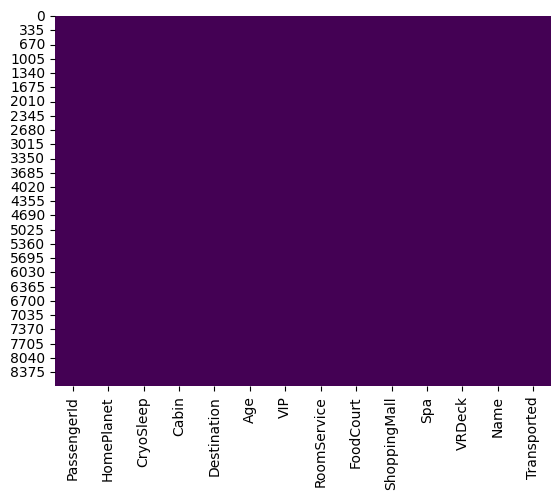

In [55]:
sns.heatmap(data.isna(), cbar=False, cmap='viridis')
print(data.describe(include=[np.number]))
print(data.describe(include=[object]))
print(data.info())

In [43]:
print(data.dtypes)
print(data.duplicated(subset = ['HomePlanet']).sum())

PassengerId      object
HomePlanet       object
CryoSleep          bool
Cabin            object
Destination      object
Age             float64
VIP                bool
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object
8690


In [50]:
data_subset = data.loc[data['HomePlanet'] == 'Earth', ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age']]
print(data_subset.head())

  HomePlanet  CryoSleep  Cabin    Destination   Age
1      Earth      False  F/0/S    TRAPPIST-1e  24.0
4      Earth      False  F/1/S    TRAPPIST-1e  16.0
5      Earth      False  F/0/P  PSO J318.5-22  44.0
6      Earth      False  F/2/S    TRAPPIST-1e  26.0
7      Earth       True  G/0/S    TRAPPIST-1e  28.0


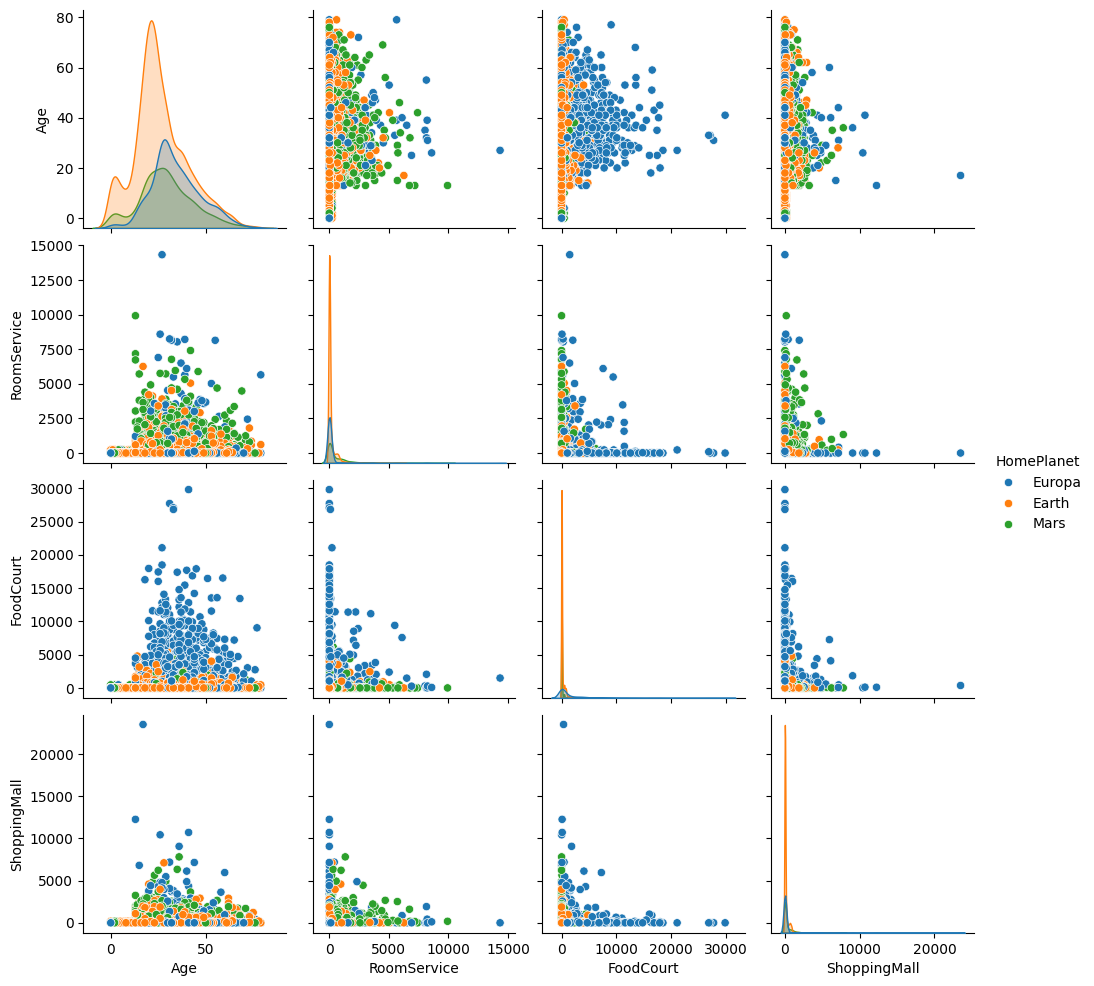

In [54]:
sns.pairplot(data, diag_kind='kde', hue='HomePlanet', vars=['Age', 'RoomService', 'FoodCourt', 'ShoppingMall'])

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Find numeric and categorical columns
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = data.select_dtypes(include=[object]).columns.tolist()

# Impute mean and mode
data[numerical_features] = data[numerical_features].fillna(data[numerical_features].mean())
data[categorical_features] = data[categorical_features].fillna(data[categorical_features].mode().iloc[0])

print(data.isna().sum().sum())
data.head()


0


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


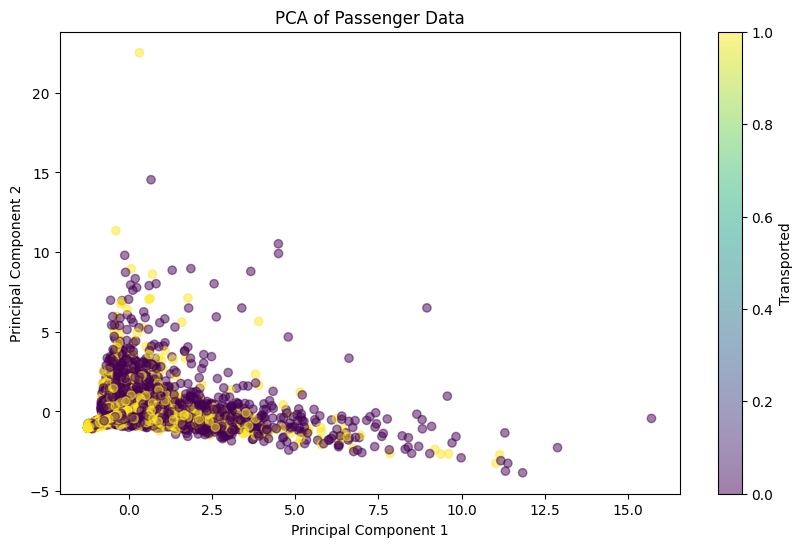

In [38]:
X = data.drop(['PassengerId', 'Transported', 'Name'], axis=1).copy()
X.rename(columns=lambda x: x.strip(), inplace=True)  # Remove leading/trailing spaces
y = data['Transported']
y = y.astype(int)  # Convert boolean to int for classification

from sklearn.preprocessing import MinMaxScaler

X_scaled = StandardScaler().fit_transform(X[numerical_features])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.title('PCA of Passenger Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Transported')
plt.show()

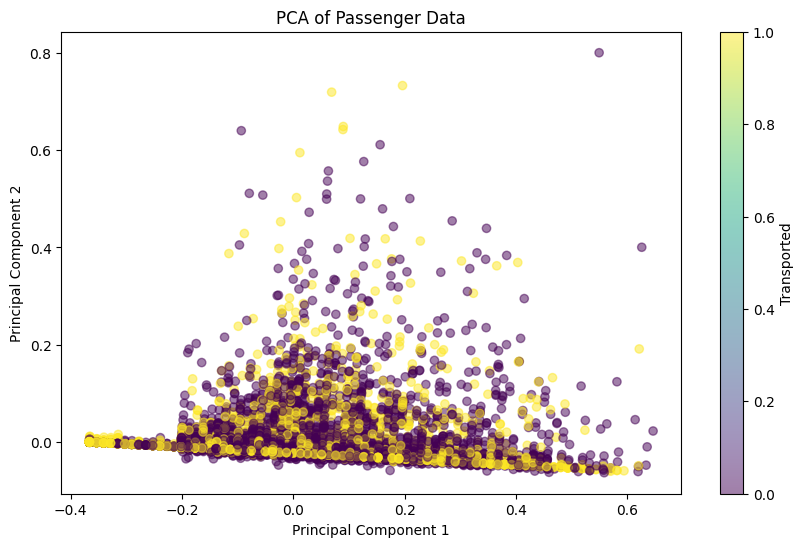

In [32]:
X = data.drop(['PassengerId', 'Transported', 'Name'], axis=1)
y = data['Transported']
y = y.astype(int)  # Convert boolean to int for classification

from sklearn.preprocessing import MinMaxScaler

X_scaled = MinMaxScaler().fit_transform(X[numerical_features])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.title('PCA of Passenger Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Transported')
plt.show()